# Notebook 3: Transfer von Novelty-Detection-Modellen auf reale TCLab-Daten

## Ziel dieses Notebooks

In diesem Notebook werden die in der Simulation trainierten Modelle auf reale TCLab-Daten übertragen.

Dabei werden drei Fragen betrachtet:

- Wie gut funktionieren Simulationsmodelle **unverändert** auf realen Normaldaten?
- Wie stark lassen sich Fehlalarme durch **Schwellen-Neukalibrierung** reduzieren?
- Wie stark verbessert sich die Erkennung, wenn Modelle auf **realen Normaldaten** nachtrainiert werden?

<div style="border:1px solid #999; padding:10px; border-radius:6px; background:#f8f8f8;">
<b>Lernziel:</b> Verstehen, dass gute Ergebnisse auf Simulationsdaten nicht automatisch gute Ergebnisse auf realen Daten bedeuten und dass einfache Anpassungsstrategien den Transfer deutlich verbessern können.
</div>

## Einordnung

Dieses Notebook baut auf den beiden vorherigen Notebooks auf:

1. Notebook 1: Datengenerierung mit TCLab-Modell und Hardware
2. Notebook 2: Offline-Novelty-Detection auf Simulationsdaten
3. Notebook 3: Transfer auf reale Daten und kurze Live-Demo

Die Grundideen zu Fensterbildung, Leakage-Vermeidung und Novelty Detection wurden bereits in Notebook 2 eingeführt und werden hier nur noch angewendet.

In [3]:
from __future__ import annotations

import json
import math
import time
from pathlib import Path
from dataclasses import dataclass
from typing import Any, Dict, List, Tuple, Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest
from sklearn.svm import OneClassSVM

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

from IPython.display import clear_output

try:
    import tclab
    TCLAB_AVAILABLE = True
except Exception:
    tclab = None
    TCLAB_AVAILABLE = False

plt.rcParams["figure.figsize"] = (12, 4)
plt.rcParams["axes.grid"] = True

GLOBAL_RANDOM_SEED = 42
np.random.seed(GLOBAL_RANDOM_SEED)
torch.manual_seed(GLOBAL_RANDOM_SEED)

print("torch:", torch.__version__)
print("tclab verfügbar:", TCLAB_AVAILABLE)

torch: 2.6.0+cpu
tclab verfügbar: True


## Konfiguration

In diesem Abschnitt werden die Datenquellen, die Merkmale, die Fensterung und die zu verwendenden Modelle festgelegt.

Für das Nachtraining kann über einen Schalter entschieden werden, ob die Modelle auf:

- nur **Simulationsdaten**, diese Möglichkeit ist eine Kontrollfunktion und entspricht Notebook 2
- nur **realen Normaldaten**
- oder einer **Kombination aus Simulations- und realen Normaldaten**

trainiert werden sollen.

In [5]:
CONFIG = {
    # Datenpfade
    "base_data_dir": "data",                         # Hauptdatenverzeichnis
    "dataset_versions": ["v1"],                      # Liste der zu ladenden Datensatzversionen

    # Merkmale
    "feature_cols": ["T1", "T2"],                   # Standardmerkmale für den Transfervergleich
    # "feature_cols": ["T1", "T2", "Q1", "Q2"],     # optionale Erweiterung

    # Quellen
    "model_source_name": "model",                   # Name der Simulationsquelle
    "real_source_name": "hardware",                 # Name der realen Quelle

    # Fensterung
    "window_length_s": 15,                          # Fensterlänge in Sekunden
    "window_step_s": 2,                             # Schrittweite der Fenster in Sekunden

    # Split für Simulationsdaten
    "sim_train_ratio": 0.60,                        # Anteil Training Simulation
    "sim_val_ratio": 0.25,                          # Anteil Validierung Simulation
    "sim_test_ratio": 0.15,                         # Anteil Test Simulation

    # Split für Realdaten
    "real_train_ratio": 0.60,                       # Anteil Training Realdaten
    "real_val_ratio": 0.25,                         # Anteil Validierung Realdaten
    "real_test_ratio": 0.15,                        # Anteil Test Realdaten

    "split_random_state": 42,                       # Seed für reproduzierbare zufällige Splits

    # Schwelle
    "target_far": 0.01,                            # Ziel-False-Alarm-Rate

    # Modelle
    "use_pca": True,                                # PCA im Vergleich verwenden
    "use_if": False,                                 # Isolation Forest im Vergleich verwenden
    "use_ocsvm": False,                              # One-Class SVM im Vergleich verwenden
    "use_shallow_ae": True,                         # Shallow Autoencoder im Vergleich verwenden

    # PCA
    "pca_n_components": 0.9,                       # erklärte Varianz für PCA

    # Isolation Forest
    "if_n_estimators": 100,                         # Anzahl Bäume im Isolation Forest
    "if_random_state": 42,                          # Seed für Isolation Forest

    # One-Class SVM
    "ocsvm_kernel": "rbf",                          # Kernel-Typ
    "ocsvm_nu": 0.01,                               # grober Anteil erwarteter Ausreißer
    "ocsvm_gamma": "scale",                         # Kernel-Skalierung

    # Autoencoder
    "ae_hidden_dim": 32,                            # Größe der verborgenen Schicht
    "ae_bottleneck_dim": 8,                         # Größe des Bottlenecks
    "ae_batch_size": 128,                           # Batch-Größe im Training
    "ae_epochs": 30,                                # Anzahl Trainings-Epochen
    "ae_learning_rate": 1e-3,                       # Lernrate
    "ae_weight_decay": 1e-5,                        # L2-Regularisierung

    # Nachtraining
    "training_data_mode": "simulation",                   # "simulation", "real", "simulation_plus_real"

    # Live-Demo
    #"selected_live_model": "PCA",                   # "PCA" oder "ShallowAE"
    "selected_live_model": "ShallowAE",

    "live_profile_global_run_id": None,             # None => automatisches Profil
    "live_plot_update_every": 5,                    # Aktualisierung des Liveplots in Sekunden
}

CONFIG

{'base_data_dir': 'data',
 'dataset_versions': ['v1'],
 'feature_cols': ['T1', 'T2'],
 'model_source_name': 'model',
 'real_source_name': 'hardware',
 'window_length_s': 15,
 'window_step_s': 2,
 'sim_train_ratio': 0.6,
 'sim_val_ratio': 0.25,
 'sim_test_ratio': 0.15,
 'real_train_ratio': 0.6,
 'real_val_ratio': 0.25,
 'real_test_ratio': 0.15,
 'split_random_state': 42,
 'target_far': 0.01,
 'use_pca': True,
 'use_if': False,
 'use_ocsvm': False,
 'use_shallow_ae': True,
 'pca_n_components': 0.9,
 'if_n_estimators': 100,
 'if_random_state': 42,
 'ocsvm_kernel': 'rbf',
 'ocsvm_nu': 0.01,
 'ocsvm_gamma': 'scale',
 'ae_hidden_dim': 32,
 'ae_bottleneck_dim': 8,
 'ae_batch_size': 128,
 'ae_epochs': 30,
 'ae_learning_rate': 0.001,
 'ae_weight_decay': 1e-05,
 'training_data_mode': 'simulation',
 'selected_live_model': 'ShallowAE',
 'live_profile_global_run_id': None,
 'live_plot_update_every': 5}

## Daten laden

Es werden sowohl Simulationsdaten als auch reale Daten aus Notebook 1 geladen. Beide liegen im gleichen Format vor und können deshalb direkt miteinander verglichen werden.

In [7]:
def read_partitioned_or_flat_dataframe(parquet_target: Path, csv_target: Path) -> pd.DataFrame:
    if parquet_target.exists() and parquet_target.is_file() and parquet_target.suffix.lower() == ".parquet":
        return pd.read_parquet(parquet_target)

    if parquet_target.exists() and parquet_target.is_dir():
        parquet_files = sorted(parquet_target.glob("*.parquet"))
        if len(parquet_files) > 0:
            return pd.concat([pd.read_parquet(f) for f in parquet_files], ignore_index=True)

    if csv_target.exists() and csv_target.is_file() and csv_target.suffix.lower() == ".csv":
        return pd.read_csv(csv_target)

    if csv_target.exists() and csv_target.is_dir():
        csv_files = sorted(csv_target.glob("*.csv"))
        if len(csv_files) > 0:
            return pd.concat([pd.read_csv(f) for f in csv_files], ignore_index=True)

    raise FileNotFoundError(
        f"Weder passende Parquet- noch CSV-Dateien gefunden:\n- {parquet_target}\n- {csv_target}"
    )


def load_one_source(version_dir: Path, source_name: str) -> Tuple[pd.DataFrame, pd.DataFrame]:
    ts_parquet = version_dir / "timeseries" / f"source={source_name}"
    ts_csv = version_dir / "timeseries" / f"source={source_name}"

    meta_parquet = version_dir / "run_metadata" / f"source={source_name}"
    meta_csv = version_dir / "run_metadata" / f"source={source_name}"

    ts_df = read_partitioned_or_flat_dataframe(ts_parquet, ts_csv)
    meta_df = read_partitioned_or_flat_dataframe(meta_parquet, meta_csv)

    return ts_df, meta_df


def load_notebook1_version(base_dir: str, version: str) -> Tuple[pd.DataFrame, pd.DataFrame, Dict[str, Any]]:
    version_dir = Path(base_dir) / version

    all_ts = []
    all_meta = []

    for source_name in [CONFIG["model_source_name"], CONFIG["real_source_name"]]:
        try:
            ts_df, meta_df = load_one_source(version_dir, source_name)
            all_ts.append(ts_df)
            all_meta.append(meta_df)
        except FileNotFoundError:
            pass

    if len(all_ts) == 0 or len(all_meta) == 0:
        raise FileNotFoundError(f"Keine Daten für Version {version} gefunden.")

    config_json = version_dir / "config" / "notebook_config.json"

    if config_json.exists():
        with open(config_json, "r", encoding="utf-8") as f:
            exported_config = json.load(f)
    else:
        exported_config = {}

    ts_df = pd.concat(all_ts, ignore_index=True).copy()
    meta_df = pd.concat(all_meta, ignore_index=True).copy()

    ts_df["dataset_version"] = version
    meta_df["dataset_version"] = version

    return ts_df, meta_df, exported_config


def load_multiple_versions(base_dir: str, versions: List[str]) -> Tuple[pd.DataFrame, pd.DataFrame, Dict[str, Dict[str, Any]]]:
    all_ts = []
    all_meta = []
    all_cfg = {}

    for version in versions:
        ts_df, meta_df, cfg = load_notebook1_version(base_dir, version)
        all_ts.append(ts_df)
        all_meta.append(meta_df)
        all_cfg[version] = cfg

    timeseries_df = pd.concat(all_ts, ignore_index=True)
    metadata_df = pd.concat(all_meta, ignore_index=True)

    return timeseries_df, metadata_df, all_cfg

In [8]:
timeseries_df, metadata_df, exported_configs = load_multiple_versions(
    base_dir=CONFIG["base_data_dir"],
    versions=CONFIG["dataset_versions"],
)

timeseries_df = timeseries_df.copy()
metadata_df = metadata_df.copy()

timeseries_df["global_run_id"] = (
    timeseries_df["dataset_version"].astype(str) + "__" + timeseries_df["run_id"].astype(str)
)
metadata_df["global_run_id"] = (
    metadata_df["dataset_version"].astype(str) + "__" + metadata_df["run_id"].astype(str)
)

timeseries_model_df = timeseries_df[timeseries_df["source"] == CONFIG["model_source_name"]].copy()
metadata_model_df = metadata_df[metadata_df["source"] == CONFIG["model_source_name"]].copy()

timeseries_real_df = timeseries_df[timeseries_df["source"] == CONFIG["real_source_name"]].copy()
metadata_real_df = metadata_df[metadata_df["source"] == CONFIG["real_source_name"]].copy()

print("Modelldaten:", timeseries_model_df.shape, metadata_model_df.shape)
print("Realdaten:", timeseries_real_df.shape, metadata_real_df.shape)

Modelldaten: (14382, 17) (24, 27)
Realdaten: (14400, 17) (24, 27)


## Visuelle Prüfung von Simulations- und Realdaten

Anstelle großer Übersichtstabellen werden die Daten direkt visuell verglichen. Ziel ist es, Unterschiede zwischen Simulation und realem Normalbetrieb schnell sichtbar zu machen.

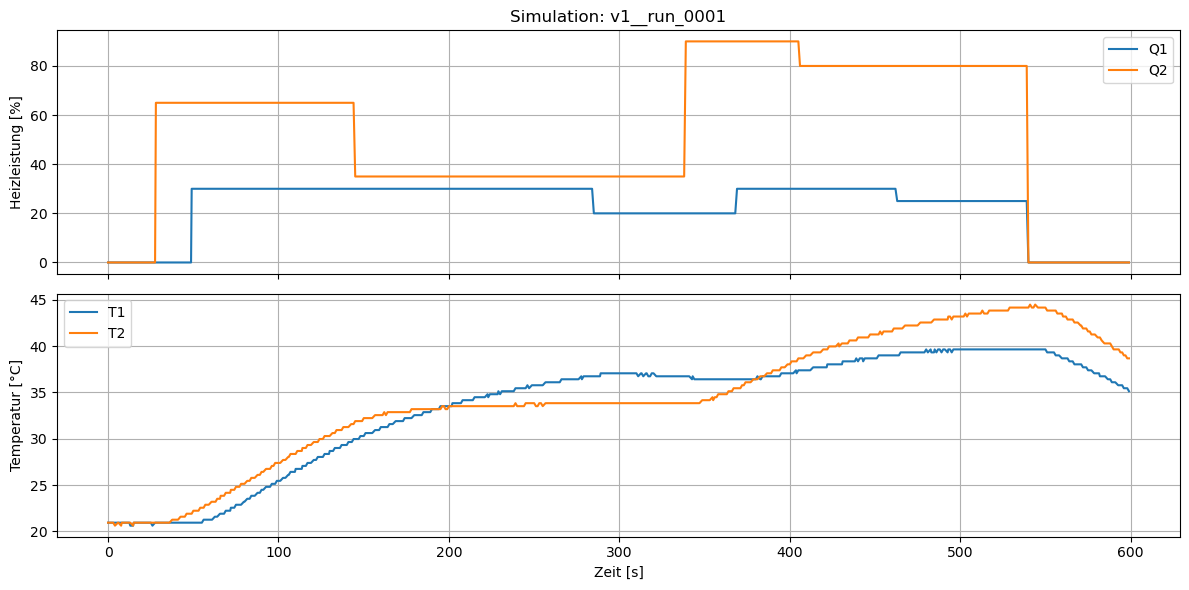

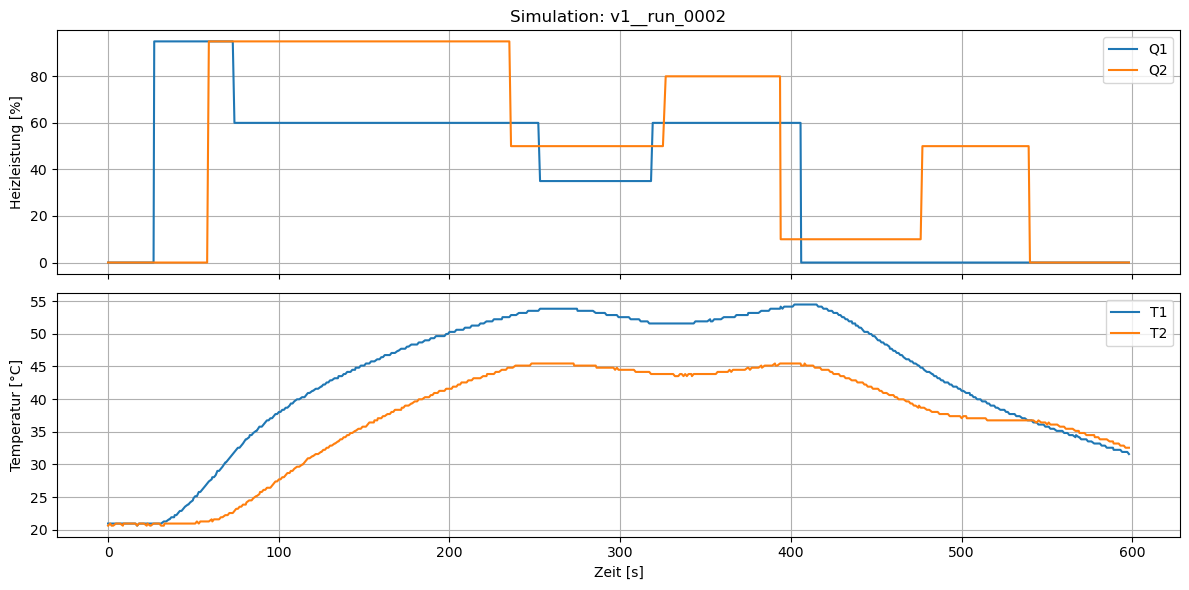

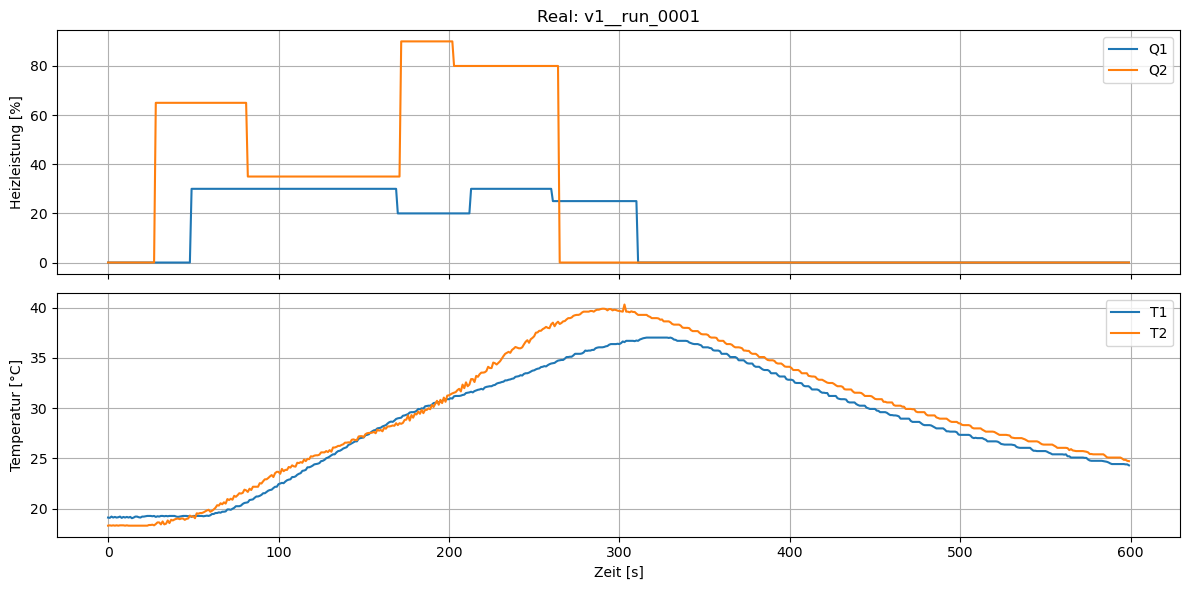

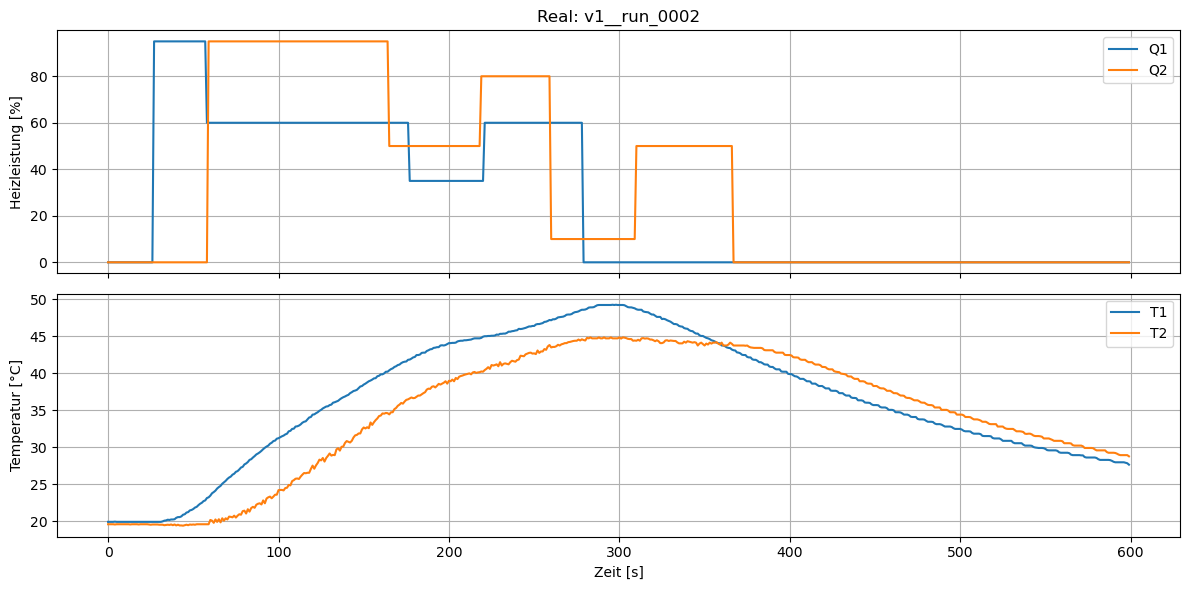

In [10]:
def plot_example_runs(
    timeseries_df: pd.DataFrame,
    metadata_df: pd.DataFrame,
    title_prefix: str,
    n_runs: int = 3,
) -> None:
    run_ids = metadata_df["global_run_id"].drop_duplicates().head(n_runs).tolist()

    for run_id in run_ids:
        df = timeseries_df[timeseries_df["global_run_id"] == run_id].sort_values("t_sec")

        fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

        axes[0].plot(df["t_sec"], df["Q1"], label="Q1")
        axes[0].plot(df["t_sec"], df["Q2"], label="Q2")
        axes[0].set_ylabel("Heizleistung [%]")
        axes[0].set_title(f"{title_prefix}: {run_id}")
        axes[0].legend()

        axes[1].plot(df["t_sec"], df["T1"], label="T1")
        axes[1].plot(df["t_sec"], df["T2"], label="T2")
        axes[1].set_xlabel("Zeit [s]")
        axes[1].set_ylabel("Temperatur [°C]")
        axes[1].legend()

        plt.tight_layout()
        plt.show()


plot_example_runs(timeseries_model_df, metadata_model_df, title_prefix="Simulation", n_runs=2)
plot_example_runs(timeseries_real_df, metadata_real_df, title_prefix="Real", n_runs=2)

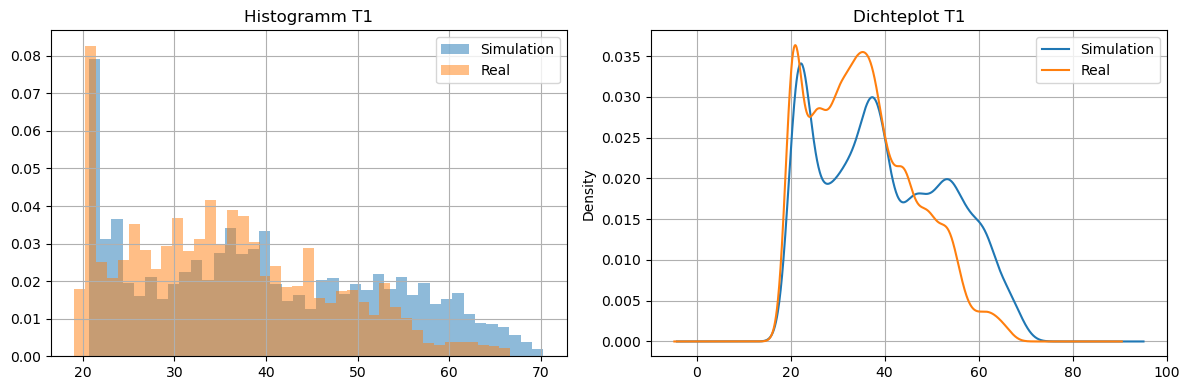

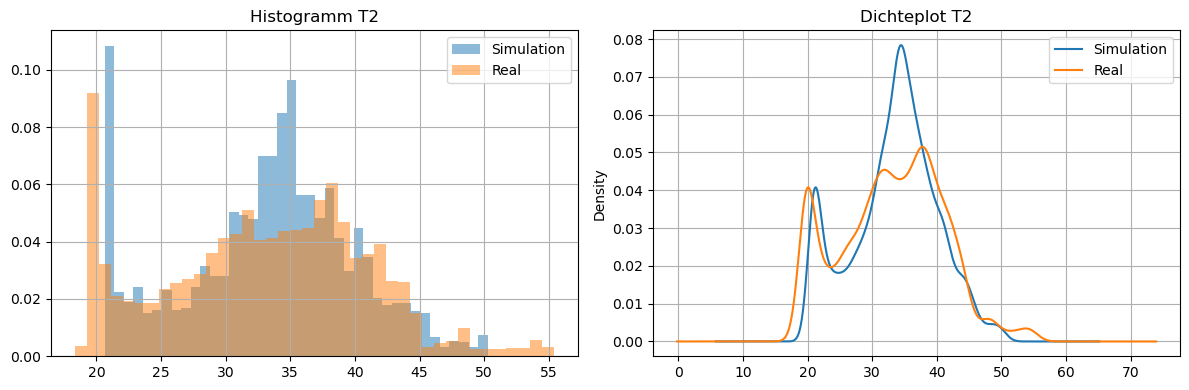

In [11]:
def plot_hist_and_density(sim_df: pd.DataFrame, real_df: pd.DataFrame, col: str) -> None:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].hist(sim_df[col], bins=40, density=True, alpha=0.5, label="Simulation")
    axes[0].hist(real_df[col], bins=40, density=True, alpha=0.5, label="Real")
    axes[0].set_title(f"Histogramm {col}")
    axes[0].legend()

    sim_df[col].plot(kind="density", ax=axes[1], label="Simulation")
    real_df[col].plot(kind="density", ax=axes[1], label="Real")
    axes[1].set_title(f"Dichteplot {col}")
    axes[1].legend()

    plt.tight_layout()
    plt.show()


plot_hist_and_density(timeseries_model_df, timeseries_real_df, "T1")
plot_hist_and_density(timeseries_model_df, timeseries_real_df, "T2")

## Fensterbildung

Die Fensterlogik wird unverändert aus Notebook 2 übernommen, damit Simulation und Realdaten mit derselben Basiseinheit verglichen werden können.

In [13]:
def get_window_params(sample_time_s: float, window_length_s: int, window_step_s: int) -> Tuple[int, int]:
    window_len = int(round(window_length_s / sample_time_s))
    window_step = int(round(window_step_s / sample_time_s))
    return window_len, window_step


def build_windows_for_one_run(
    run_df: pd.DataFrame,
    feature_cols: List[str],
    window_length_s: int,
    window_step_s: int,
) -> Tuple[np.ndarray, pd.DataFrame]:
    run_df = run_df.sort_values("t_sec").reset_index(drop=True)
    sample_time_s = float(run_df["sample_time_s"].iloc[0])
    window_len, window_step = get_window_params(sample_time_s, window_length_s, window_step_s)

    values = run_df[feature_cols].to_numpy(dtype=float)
    n = len(values)

    windows = []
    rows = []

    for start in range(0, n - window_len + 1, window_step):
        end = start + window_len
        x_win = values[start:end]

        windows.append(x_win)
        rows.append({
            "global_run_id": run_df["global_run_id"].iloc[0],
            "dataset_version": run_df["dataset_version"].iloc[0],
            "run_id": run_df["run_id"].iloc[0],
            "profile_family": run_df["profile_family"].iloc[0],
            "sample_time_s": sample_time_s,
            "window_start_idx": start,
            "window_end_idx": end - 1,
            "window_start_s": float(run_df["t_sec"].iloc[start]),
            "window_end_s": float(run_df["t_sec"].iloc[end - 1]),
        })

    return np.asarray(windows, dtype=float), pd.DataFrame(rows)


def build_all_windows(
    timeseries_df: pd.DataFrame,
    feature_cols: List[str],
    window_length_s: int,
    window_step_s: int,
) -> Tuple[np.ndarray, pd.DataFrame]:
    all_windows = []
    all_meta = []

    for global_run_id, run_df in timeseries_df.groupby("global_run_id"):
        x, m = build_windows_for_one_run(
            run_df=run_df,
            feature_cols=feature_cols,
            window_length_s=window_length_s,
            window_step_s=window_step_s,
        )
        all_windows.append(x)
        all_meta.append(m)

    X = np.concatenate(all_windows, axis=0)
    meta = pd.concat(all_meta, ignore_index=True)
    return X, meta

## Run-weiser Split der Simulations- und Realdaten

Für Simulation und Realdaten werden separate Splits auf Run-Ebene erzeugt. Dadurch bleiben Trainings-, Validierungs- und Testruns sauber getrennt.

In [15]:
def build_stratify_label(meta: pd.DataFrame) -> pd.Series:
    profile = meta["profile_family"].astype(str)
    counts = profile.value_counts()
    rare = set(counts[counts < 3].index.tolist())
    profile = profile.where(~profile.isin(rare), "other")
    return profile


def split_runs_runwise(
    metadata_df: pd.DataFrame,
    train_ratio: float,
    val_ratio: float,
    test_ratio: float,
    random_state: int,
) -> pd.DataFrame:
    run_meta = metadata_df[["global_run_id", "dataset_version", "profile_family"]].drop_duplicates().reset_index(drop=True)
    stratify_labels = build_stratify_label(run_meta)

    train_val_runs, test_runs = train_test_split(
        run_meta,
        test_size=test_ratio,
        random_state=random_state,
        stratify=stratify_labels,
    )

    train_val_stratify = build_stratify_label(train_val_runs)
    relative_val_ratio = val_ratio / (train_ratio + val_ratio)

    train_runs, val_runs = train_test_split(
        train_val_runs,
        test_size=relative_val_ratio,
        random_state=random_state,
        stratify=train_val_stratify,
    )

    train_runs = train_runs.assign(split="train")
    val_runs = val_runs.assign(split="val")
    test_runs = test_runs.assign(split="test")

    return pd.concat([train_runs, val_runs, test_runs], ignore_index=True)

In [16]:
sim_split_df = split_runs_runwise(
    metadata_df=metadata_model_df,
    train_ratio=CONFIG["sim_train_ratio"],
    val_ratio=CONFIG["sim_val_ratio"],
    test_ratio=CONFIG["sim_test_ratio"],
    random_state=CONFIG["split_random_state"],
)

real_split_df = split_runs_runwise(
    metadata_df=metadata_real_df,
    train_ratio=CONFIG["real_train_ratio"],
    val_ratio=CONFIG["real_val_ratio"],
    test_ratio=CONFIG["real_test_ratio"],
    random_state=CONFIG["split_random_state"],
)

timeseries_model_df = timeseries_model_df.merge(
    sim_split_df[["global_run_id", "split"]],
    on="global_run_id",
    how="left",
)

metadata_model_df = metadata_model_df.drop(columns=["split"], errors="ignore").merge(
    sim_split_df[["global_run_id", "split"]],
    on="global_run_id",
    how="left",
)

timeseries_real_df = timeseries_real_df.merge(
    real_split_df[["global_run_id", "split"]],
    on="global_run_id",
    how="left",
)

metadata_real_df = metadata_real_df.drop(columns=["split"], errors="ignore").merge(
    real_split_df[["global_run_id", "split"]],
    on="global_run_id",
    how="left",
)

print(metadata_model_df.groupby("split").size())
print(metadata_real_df.groupby("split").size())

split
test      4
train    14
val       6
dtype: int64
split
test      4
train    14
val       6
dtype: int64


In [17]:
X_model_all, model_window_meta = build_all_windows(
    timeseries_df=timeseries_model_df,
    feature_cols=CONFIG["feature_cols"],
    window_length_s=CONFIG["window_length_s"],
    window_step_s=CONFIG["window_step_s"],
)

X_real_all, real_window_meta = build_all_windows(
    timeseries_df=timeseries_real_df,
    feature_cols=CONFIG["feature_cols"],
    window_length_s=CONFIG["window_length_s"],
    window_step_s=CONFIG["window_step_s"],
)

model_window_meta = model_window_meta.merge(
    metadata_model_df[["global_run_id", "split"]].drop_duplicates(),
    on="global_run_id",
    how="left",
)

real_window_meta = real_window_meta.merge(
    metadata_real_df[["global_run_id", "split"]].drop_duplicates(),
    on="global_run_id",
    how="left",
)

print("Simulationsfenster:", X_model_all.shape, model_window_meta.shape)
print("Realfenster:", X_real_all.shape, real_window_meta.shape)

Simulationsfenster: (7028, 15, 2) (7028, 10)
Realfenster: (7032, 15, 2) (7032, 10)


## Modelle auf Simulationsdaten aufbauen

Die Modelle werden für den Zero-shot-Transfer zunächst auf Simulationsdaten trainiert, Dies geschieht analog zu Notebook 2 - beachten Sie zu Beginn, dass SIe gleiche Parameter nutzen!

In [19]:
def flatten_windows(X: np.ndarray) -> np.ndarray:
    return X.reshape(X.shape[0], -1)


def compute_threshold(scores: np.ndarray, target_far: float) -> float:
    return float(np.quantile(scores, 1.0 - target_far))


def compute_far_and_alarms_per_hour(scores: np.ndarray, threshold: float, window_step_s: int) -> Dict[str, float]:
    alarm = (scores > threshold).astype(int)
    far = float(alarm.mean())
    alarms_per_hour = float(far * (3600.0 / window_step_s))
    return {"far": far, "alarms_per_hour": alarms_per_hour}


def get_split_arrays(X_all: np.ndarray, meta_all: pd.DataFrame, split_name: str) -> Tuple[np.ndarray, pd.DataFrame]:
    idx = meta_all["split"] == split_name
    return X_all[idx.to_numpy()], meta_all[idx].reset_index(drop=True)

In [20]:
X_model_train_raw, meta_model_train = get_split_arrays(X_model_all, model_window_meta, "train")
X_model_val_raw, meta_model_val = get_split_arrays(X_model_all, model_window_meta, "val")
X_model_test_raw, meta_model_test = get_split_arrays(X_model_all, model_window_meta, "test")

sim_scaler = StandardScaler()
sim_scaler.fit(flatten_windows(X_model_train_raw))

X_model_train_vec = sim_scaler.transform(flatten_windows(X_model_train_raw))
X_model_val_vec = sim_scaler.transform(flatten_windows(X_model_val_raw))
X_model_test_vec = sim_scaler.transform(flatten_windows(X_model_test_raw))

X_real_train_raw, meta_real_train = get_split_arrays(X_real_all, real_window_meta, "train")
X_real_val_raw, meta_real_val = get_split_arrays(X_real_all, real_window_meta, "val")
X_real_test_raw, meta_real_test = get_split_arrays(X_real_all, real_window_meta, "test")

X_real_train_vec_zero = sim_scaler.transform(flatten_windows(X_real_train_raw))
X_real_val_vec_zero = sim_scaler.transform(flatten_windows(X_real_val_raw))
X_real_test_vec_zero = sim_scaler.transform(flatten_windows(X_real_test_raw))

In [21]:
def pca_score(model: PCA, X_vec: np.ndarray) -> np.ndarray:
    X_recon = model.inverse_transform(model.transform(X_vec))
    return np.mean((X_vec - X_recon) ** 2, axis=1)


def if_score(model: IsolationForest, X_vec: np.ndarray) -> np.ndarray:
    return -model.score_samples(X_vec)


def ocsvm_score(model: OneClassSVM, X_vec: np.ndarray) -> np.ndarray:
    return -model.decision_function(X_vec).ravel()

In [22]:
class ShallowAutoencoder(nn.Module):
    def __init__(self, input_dim: int, hidden_dim: int, bottleneck_dim: int):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, bottleneck_dim),
            nn.ReLU(),
        )
        self.decoder = nn.Sequential(
            nn.Linear(bottleneck_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, input_dim),
        )

    def forward(self, x):
        z = self.encoder(x)
        x_hat = self.decoder(z)
        return x_hat


def make_loader(X_vec: np.ndarray, batch_size: int, shuffle: bool) -> DataLoader:
    x = torch.tensor(X_vec, dtype=torch.float32)
    ds = TensorDataset(x, x)
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle)


def train_autoencoder(
    model: nn.Module,
    train_loader: DataLoader,
    val_loader: DataLoader,
    epochs: int,
    learning_rate: float,
    weight_decay: float,
    device: torch.device,
) -> Dict[str, List[float]]:
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
    history = {"train_loss": [], "val_loss": []}

    model.to(device)

    for _ in range(epochs):
        model.train()
        train_losses = []

        for xb, yb in train_loader:
            xb = xb.to(device)
            yb = yb.to(device)

            optimizer.zero_grad()
            y_hat = model(xb)
            loss = criterion(y_hat, yb)
            loss.backward()
            optimizer.step()
            train_losses.append(loss.item())

        model.eval()
        val_losses = []

        with torch.no_grad():
            for xb, yb in val_loader:
                xb = xb.to(device)
                yb = yb.to(device)
                y_hat = model(xb)
                loss = criterion(y_hat, yb)
                val_losses.append(loss.item())

        history["train_loss"].append(float(np.mean(train_losses)))
        history["val_loss"].append(float(np.mean(val_losses)))

    return history


def ae_score(model: nn.Module, X_vec: np.ndarray, device: torch.device) -> np.ndarray:
    model.eval()
    x = torch.tensor(X_vec, dtype=torch.float32).to(device)
    with torch.no_grad():
        x_hat = model(x)
    return torch.mean((x - x_hat) ** 2, dim=1).cpu().numpy()

In [23]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
trained_sim_models = {}
sim_thresholds = {}

if CONFIG["use_pca"]:
    pca_model = PCA(n_components=CONFIG["pca_n_components"], random_state=GLOBAL_RANDOM_SEED)
    pca_model.fit(X_model_train_vec)
    trained_sim_models["PCA"] = {"model": pca_model, "scaler": sim_scaler}
    sim_thresholds["PCA"] = compute_threshold(pca_score(pca_model, X_model_val_vec), CONFIG["target_far"])

if CONFIG["use_if"]:
    if_model = IsolationForest(
        n_estimators=CONFIG["if_n_estimators"],
        random_state=CONFIG["if_random_state"],
    )
    if_model.fit(X_model_train_vec)
    trained_sim_models["IsolationForest"] = {"model": if_model, "scaler": sim_scaler}
    sim_thresholds["IsolationForest"] = compute_threshold(if_score(if_model, X_model_val_vec), CONFIG["target_far"])

if CONFIG["use_ocsvm"]:
    ocsvm_model = OneClassSVM(
        kernel=CONFIG["ocsvm_kernel"],
        nu=CONFIG["ocsvm_nu"],
        gamma=CONFIG["ocsvm_gamma"],
    )
    ocsvm_model.fit(X_model_train_vec)
    trained_sim_models["OneClassSVM"] = {"model": ocsvm_model, "scaler": sim_scaler}
    sim_thresholds["OneClassSVM"] = compute_threshold(ocsvm_score(ocsvm_model, X_model_val_vec), CONFIG["target_far"])

if CONFIG["use_shallow_ae"]:
    input_dim = X_model_train_vec.shape[1]
    ae_model = ShallowAutoencoder(
        input_dim=input_dim,
        hidden_dim=CONFIG["ae_hidden_dim"],
        bottleneck_dim=CONFIG["ae_bottleneck_dim"],
    )

    ae_history = train_autoencoder(
        model=ae_model,
        train_loader=make_loader(X_model_train_vec, CONFIG["ae_batch_size"], shuffle=True),
        val_loader=make_loader(X_model_val_vec, CONFIG["ae_batch_size"], shuffle=False),
        epochs=CONFIG["ae_epochs"],
        learning_rate=CONFIG["ae_learning_rate"],
        weight_decay=CONFIG["ae_weight_decay"],
        device=device,
    )

    trained_sim_models["ShallowAE"] = {"model": ae_model, "scaler": sim_scaler}
    sim_thresholds["ShallowAE"] = compute_threshold(ae_score(ae_model, X_model_val_vec, device), CONFIG["target_far"])

trained_sim_models.keys(), sim_thresholds

(dict_keys(['PCA', 'ShallowAE']),
 {'PCA': 0.005622523608226982, 'ShallowAE': 0.004720154548995201})

## Zero-shot-Transfer auf reale Normaldaten

Die Simulationsmodelle werden nun unverändert auf reale Normaldaten angewendet. Ziel ist es, den Sim-to-Real-Gap sichtbar zu machen.

Typischerweise erhöht sich die Alarmrate, wenn Normaldaten genutzt werden. Es werde deutlich mehr Alarme detektiert als die FAR vorgibt.

In [25]:
def score_with_model(model_name: str, model_obj: Any, X_vec: np.ndarray) -> np.ndarray:
    if model_name == "PCA":
        return pca_score(model_obj, X_vec)
    if model_name == "IsolationForest":
        return if_score(model_obj, X_vec)
    if model_name == "OneClassSVM":
        return ocsvm_score(model_obj, X_vec)
    if model_name == "ShallowAE":
        return ae_score(model_obj, X_vec, device)
    raise ValueError(f"Unbekanntes Modell: {model_name}")


zero_shot_rows = []

for model_name, artifacts in trained_sim_models.items():
    model_obj = artifacts["model"]
    threshold = sim_thresholds[model_name]

    real_test_scores = score_with_model(model_name, model_obj, X_real_test_vec_zero)
    metrics = compute_far_and_alarms_per_hour(real_test_scores, threshold, CONFIG["window_step_s"])

    zero_shot_rows.append({
        "model": model_name,
        "strategy": "zero_shot",
        "threshold": threshold,
        "far_real_test": metrics["far"],
        "alarms_per_hour_real_test": metrics["alarms_per_hour"],
        "score_mean_real_test": float(np.mean(real_test_scores)),
        "score_std_real_test": float(np.std(real_test_scores)),
    })

zero_shot_df = pd.DataFrame(zero_shot_rows).sort_values("model").reset_index(drop=True)
zero_shot_df

,model,strategy,threshold,far_real_test,alarms_per_hour_real_test,score_mean_real_test,score_std_real_test
0,PCA,zero_shot,0.005623,0.005973,10.750853,0.001224,0.000956
1,ShallowAE,zero_shot,0.004720,0.011945,21.501706,0.001297,0.000974


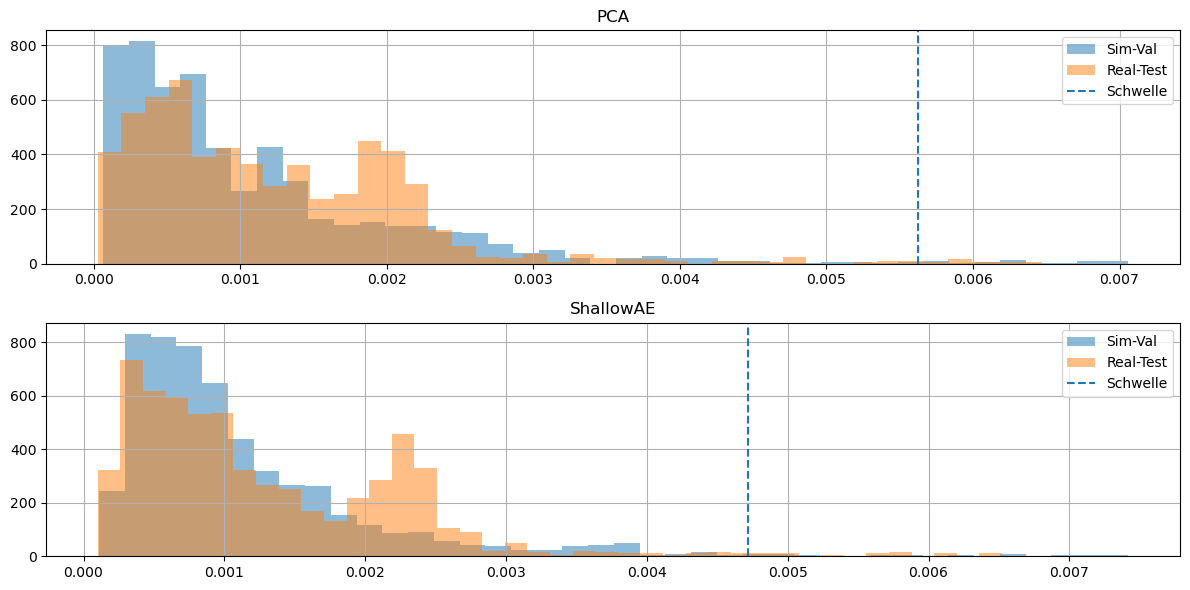

In [26]:
def plot_zero_shot_score_distributions(
    trained_models: Dict[str, Dict[str, Any]],
    thresholds: Dict[str, float],
) -> None:
    n_models = len(trained_models)
    fig, axes = plt.subplots(n_models, 1, figsize=(12, 3 * n_models), sharex=False)

    if n_models == 1:
        axes = [axes]

    for ax, (model_name, artifacts) in zip(axes, trained_models.items()):
        model_obj = artifacts["model"]

        sim_scores = score_with_model(model_name, model_obj, X_model_val_vec)
        real_scores = score_with_model(model_name, model_obj, X_real_test_vec_zero)

        ax.hist(sim_scores, bins=40, density=True, alpha=0.5, label="Sim-Val")
        ax.hist(real_scores, bins=40, density=True, alpha=0.5, label="Real-Test")
        ax.axvline(thresholds[model_name], linestyle="--", label="Schwelle")
        ax.set_title(model_name)
        ax.legend()

    plt.tight_layout()
    plt.show()


plot_zero_shot_score_distributions(trained_sim_models, sim_thresholds)

## Anpassungsstrategie A: Schwelle neu kalibrieren

In diesem Schritt bleibt das Modell unverändert. Es wird nur der Schwellenwert mit realen Normaldaten neu bestimmt.

In [28]:
recalibrated_rows = []
recalibrated_thresholds = {}

for model_name, artifacts in trained_sim_models.items():
    model_obj = artifacts["model"]

    real_val_scores = score_with_model(model_name, model_obj, X_real_val_vec_zero)
    real_test_scores = score_with_model(model_name, model_obj, X_real_test_vec_zero)

    threshold = compute_threshold(real_val_scores, CONFIG["target_far"])
    recalibrated_thresholds[model_name] = threshold

    metrics = compute_far_and_alarms_per_hour(real_test_scores, threshold, CONFIG["window_step_s"])

    recalibrated_rows.append({
        "model": model_name,
        "strategy": "threshold_recalibrated",
        "threshold": threshold,
        "far_real_test": metrics["far"],
        "alarms_per_hour_real_test": metrics["alarms_per_hour"],
        "score_mean_real_test": float(np.mean(real_test_scores)),
        "score_std_real_test": float(np.std(real_test_scores)),
    })

recalibrated_df = pd.DataFrame(recalibrated_rows).sort_values("model").reset_index(drop=True)
recalibrated_df

,model,strategy,threshold,far_real_test,alarms_per_hour_real_test,score_mean_real_test,score_std_real_test
0,PCA,threshold_recalibrated,0.005549,0.007679,13.822526,0.001224,0.000956
1,ShallowAE,threshold_recalibrated,0.005351,0.007679,13.822526,0.001297,0.000974


## Anpassungsstrategie B: Modelle auf realen Normaldaten nachtrainieren

In der Praxis ist es oft sinnvoll, Modelle auf einer Kombination aus Simulations- und realen Normaldaten zu trainieren. In diesem Notebook wird standardmäßig ein Nachtraining durchgeführt. Über den Schalter `training_data_mode` kann `simulation` (entspricht dem bisherigen Training plus weitere Simulationsdaten) oder `simulation_plus_real` oder `real` (entspricht einem erneuten Training NUR mit Daten des realen TCLab) gewählt werden.

In [30]:
def select_training_data_by_mode(mode: str):
    if mode == "simulation":
        X_train_raw = X_model_train_raw
        X_val_raw = X_model_val_raw
    elif mode == "real":
        X_train_raw = X_real_train_raw
        X_val_raw = X_real_val_raw
    elif mode == "simulation_plus_real":
        X_train_raw = np.concatenate([X_model_train_raw, X_real_train_raw], axis=0)
        X_val_raw = np.concatenate([X_model_val_raw, X_real_val_raw], axis=0)
    else:
        raise ValueError(f"Unbekannter training_data_mode: {mode}")

    scaler = StandardScaler()
    scaler.fit(flatten_windows(X_train_raw))

    X_train_vec = scaler.transform(flatten_windows(X_train_raw))
    X_val_vec = scaler.transform(flatten_windows(X_val_raw))
    X_real_test_vec = scaler.transform(flatten_windows(X_real_test_raw))

    return X_train_vec, X_val_vec, X_real_test_vec, scaler


X_retrain_train_vec, X_retrain_val_vec, X_retrain_real_test_vec, retrain_scaler = select_training_data_by_mode(
    CONFIG["training_data_mode"]
)

In [31]:
retrained_models = {}
retrained_thresholds = {}

if CONFIG["use_pca"]:
    pca_re = PCA(n_components=CONFIG["pca_n_components"], random_state=GLOBAL_RANDOM_SEED)
    pca_re.fit(X_retrain_train_vec)
    retrained_models["PCA"] = {"model": pca_re, "scaler": retrain_scaler}
    retrained_thresholds["PCA"] = compute_threshold(pca_score(pca_re, X_retrain_val_vec), CONFIG["target_far"])

if CONFIG["use_if"]:
    if_re = IsolationForest(
        n_estimators=CONFIG["if_n_estimators"],
        random_state=CONFIG["if_random_state"],
    )
    if_re.fit(X_retrain_train_vec)
    retrained_models["IsolationForest"] = {"model": if_re, "scaler": retrain_scaler}
    retrained_thresholds["IsolationForest"] = compute_threshold(if_score(if_re, X_retrain_val_vec), CONFIG["target_far"])

if CONFIG["use_ocsvm"]:
    ocsvm_re = OneClassSVM(
        kernel=CONFIG["ocsvm_kernel"],
        nu=CONFIG["ocsvm_nu"],
        gamma=CONFIG["ocsvm_gamma"],
    )
    ocsvm_re.fit(X_retrain_train_vec)
    retrained_models["OneClassSVM"] = {"model": ocsvm_re, "scaler": retrain_scaler}
    retrained_thresholds["OneClassSVM"] = compute_threshold(ocsvm_score(ocsvm_re, X_retrain_val_vec), CONFIG["target_far"])

if CONFIG["use_shallow_ae"]:
    input_dim = X_retrain_train_vec.shape[1]
    ae_re = ShallowAutoencoder(
        input_dim=input_dim,
        hidden_dim=CONFIG["ae_hidden_dim"],
        bottleneck_dim=CONFIG["ae_bottleneck_dim"],
    )

    ae_history_re = train_autoencoder(
        model=ae_re,
        train_loader=make_loader(X_retrain_train_vec, CONFIG["ae_batch_size"], shuffle=True),
        val_loader=make_loader(X_retrain_val_vec, CONFIG["ae_batch_size"], shuffle=False),
        epochs=CONFIG["ae_epochs"],
        learning_rate=CONFIG["ae_learning_rate"],
        weight_decay=CONFIG["ae_weight_decay"],
        device=device,
    )

    retrained_models["ShallowAE"] = {"model": ae_re, "scaler": retrain_scaler}
    retrained_thresholds["ShallowAE"] = compute_threshold(ae_score(ae_re, X_retrain_val_vec, device), CONFIG["target_far"])

In [32]:
retrained_rows = []

for model_name, artifacts in retrained_models.items():
    model_obj = artifacts["model"]
    threshold = retrained_thresholds[model_name]

    real_test_scores = score_with_model(model_name, model_obj, X_retrain_real_test_vec)
    metrics = compute_far_and_alarms_per_hour(real_test_scores, threshold, CONFIG["window_step_s"])

    retrained_rows.append({
        "model": model_name,
        "strategy": f"retrained_{CONFIG['training_data_mode']}",
        "threshold": threshold,
        "far_real_test": metrics["far"],
        "alarms_per_hour_real_test": metrics["alarms_per_hour"],
        "score_mean_real_test": float(np.mean(real_test_scores)),
        "score_std_real_test": float(np.std(real_test_scores)),
    })

retrained_df = pd.DataFrame(retrained_rows).sort_values("model").reset_index(drop=True)
retrained_df

,model,strategy,threshold,far_real_test,alarms_per_hour_real_test,score_mean_real_test,score_std_real_test
0,PCA,retrained_simulation,0.005623,0.005973,10.750853,0.001224,0.000956
1,ShallowAE,retrained_simulation,0.004898,0.011945,21.501706,0.001360,0.001025


## Vergleich der Strategien

Zum Vergleich werden drei Strategien gegenübergestellt:

- Zero-shot-Transfer
- nur Schwelle neu kalibrieren
- Modelle auf ausgewählten Normaldaten nachtrainieren

In [34]:
comparison_df = pd.concat(
    [zero_shot_df, recalibrated_df, retrained_df],
    ignore_index=True,
).sort_values(["model", "strategy"]).reset_index(drop=True)

comparison_df

,model,strategy,threshold,far_real_test,alarms_per_hour_real_test,score_mean_real_test,score_std_real_test
0,PCA,retrained_simulation,0.005623,0.005973,10.750853,0.001224,0.000956
1,PCA,threshold_recalibrated,0.005549,0.007679,13.822526,0.001224,0.000956
2,PCA,zero_shot,0.005623,0.005973,10.750853,0.001224,0.000956
3,ShallowAE,retrained_simulation,0.004898,0.011945,21.501706,0.001360,0.001025
4,ShallowAE,threshold_recalibrated,0.005351,0.007679,13.822526,0.001297,0.000974
5,ShallowAE,zero_shot,0.004720,0.011945,21.501706,0.001297,0.000974


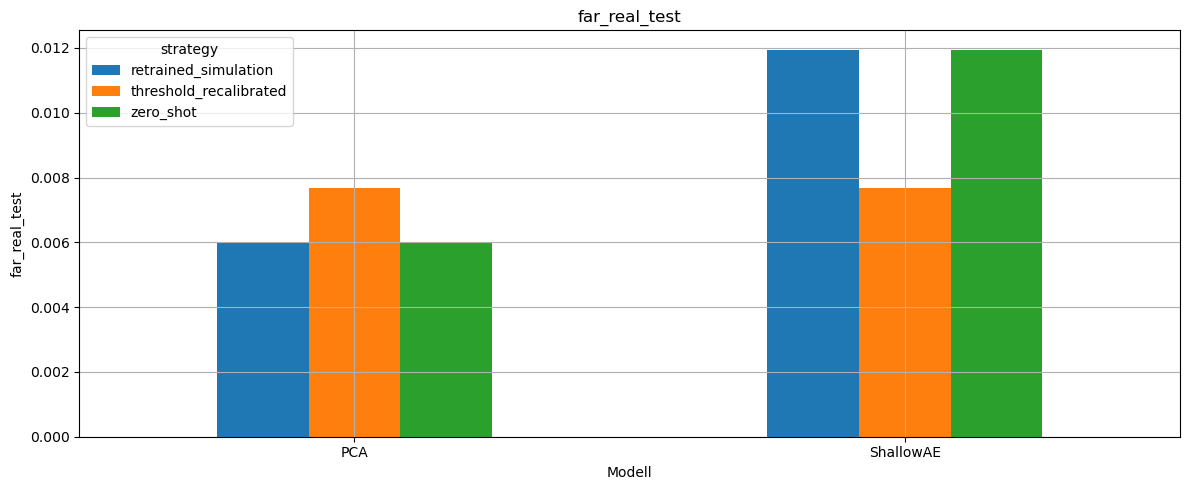

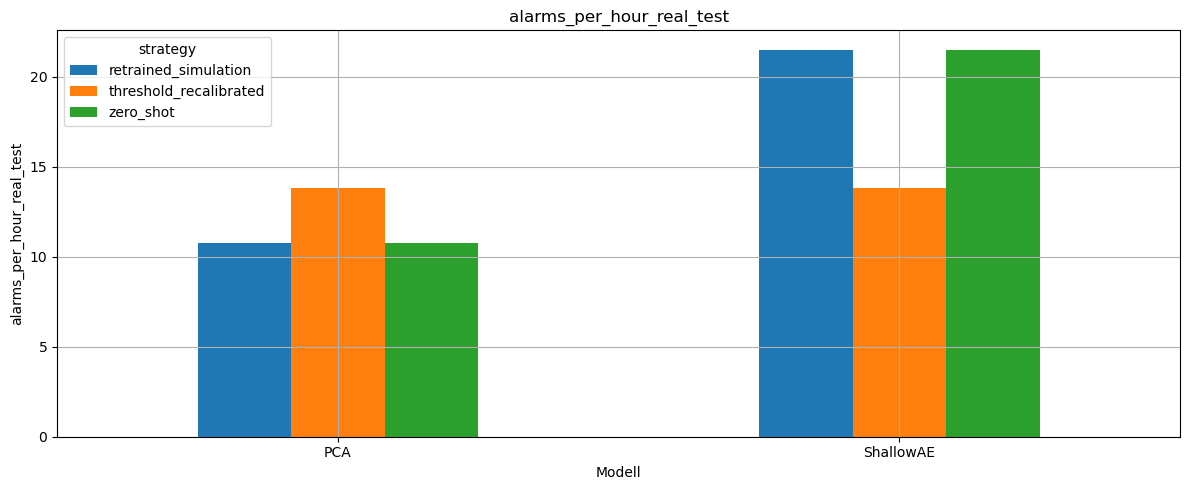

In [35]:
def plot_strategy_comparison(comparison_df: pd.DataFrame, metric_col: str) -> None:
    pivot_df = comparison_df.pivot(index="model", columns="strategy", values=metric_col)

    ax = pivot_df.plot(kind="bar", figsize=(12, 5))
    ax.set_title(metric_col)
    ax.set_ylabel(metric_col)
    ax.set_xlabel("Modell")
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()


plot_strategy_comparison(comparison_df, "far_real_test")
plot_strategy_comparison(comparison_df, "alarms_per_hour_real_test")

## Auswahl eines Modells für die Live-Demo

Für die qualitative Live-Demo am TCLab wird nur ein Modell ausgewählt. Dadurch bleibt der abschließende Hardwareteil übersichtlich.

In [37]:
selected_live_model = CONFIG["selected_live_model"]
print("Ausgewähltes Modell für die Live-Demo:", selected_live_model)

live_artifacts = retrained_models[selected_live_model]
live_threshold = retrained_thresholds[selected_live_model]

Ausgewähltes Modell für die Live-Demo: ShallowAE


## Profil für den Livebetrieb auswählen

Für die Live-Demo wird ein bekanntes Profil aus dem Datensatz gewählt und auf der Hardware erneut abgefahren.

In [39]:
if CONFIG["live_profile_global_run_id"] is None:
    live_profile_global_run_id = metadata_model_df["global_run_id"].iloc[0]
else:
    live_profile_global_run_id = CONFIG["live_profile_global_run_id"]

live_profile_df = timeseries_model_df[
    timeseries_model_df["global_run_id"] == live_profile_global_run_id
].sort_values("t_sec").reset_index(drop=True)

print("Live-Profil:", live_profile_global_run_id)
live_profile_df[["t_sec", "Q1", "Q2"]].head()

Live-Profil: v1__run_0001


,t_sec,Q1,Q2
0,0.00,0.0,0.0
1,1.46,0.0,0.0
2,2.05,0.0,0.0
3,3.03,0.0,0.0
4,4.05,0.0,0.0


## Qualitative Live-Demo auf dem TCLab

Dieser Abschnitt ist als einfacher Praxisanhang gedacht. Es wird ein bekanntes Profil gefahren, der Score des ausgewählten Modells live berechnet und der Alarmstatus angezeigt.

Die Live-Demo ist qualitativ. Ziel ist nicht die vollständige Auswertung, sondern die Beobachtung des Modellverhaltens unter realen Einflüssen.

In [41]:
def build_clock(total_time_s: int, sample_time_s: float):
    try:
        return tclab.clock(total_time_s, step=sample_time_s)
    except TypeError:
        return tclab.clock(total_time_s, sample_time_s)


def score_live_window(model_name: str, artifacts: Dict[str, Any], threshold: float, window_array: np.ndarray) -> Tuple[float, int]:
    scaler = artifacts["scaler"]
    model_obj = artifacts["model"]

    x_vec = scaler.transform(window_array.reshape(1, -1))

    score = float(score_with_model(model_name, model_obj, x_vec)[0])
    alarm = int(score > threshold)
    return score, alarm

In [42]:
def run_live_demo_with_selected_model(
    profile_df: pd.DataFrame,
    feature_cols: List[str],
    model_name: str,
    artifacts: Dict[str, Any],
    threshold: float,
    window_length_s: int,
    plot_update_every: int = 5,
) -> pd.DataFrame:
    if not TCLAB_AVAILABLE:
        raise RuntimeError("tclab ist nicht verfügbar.")

    sample_time_s = float(profile_df["sample_time_s"].iloc[0])
    total_time_s = int(profile_df["t_sec"].max()) + 1
    window_len, _ = get_window_params(sample_time_s, window_length_s, CONFIG["window_step_s"])

    buffer_rows = []
    records = []

    with tclab.TCLab() as lab:
        lab.Q1(0)
        lab.Q2(0)

        for k, t_sec in enumerate(build_clock(total_time_s, sample_time_s)):
            q1 = float(profile_df["Q1"].iloc[k])
            q2 = float(profile_df["Q2"].iloc[k])

            lab.Q1(q1)
            lab.Q2(q2)

            row = {
                "t_sec": float(t_sec),
                "Q1": q1,
                "Q2": q2,
                "T1": float(lab.T1),
                "T2": float(lab.T2),
            }
            buffer_rows.append(row)

            if len(buffer_rows) >= window_len:
                current_window = pd.DataFrame(buffer_rows[-window_len:])[feature_cols].to_numpy(dtype=float)
                score, alarm = score_live_window(model_name, artifacts, threshold, current_window)
            else:
                score, alarm = np.nan, 0

            row["score"] = score
            row["alarm"] = alarm
            records.append(row)

            if (k % plot_update_every == 0) or (k == total_time_s - 1):
                clear_output(wait=True)
                live_df = pd.DataFrame(records)

                fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)

                axes[0].plot(live_df["t_sec"], live_df["Q1"], label="Q1")
                axes[0].plot(live_df["t_sec"], live_df["Q2"], label="Q2")
                axes[0].set_ylabel("Heizleistung [%]")
                axes[0].legend()

                axes[1].plot(live_df["t_sec"], live_df["T1"], label="T1")
                axes[1].plot(live_df["t_sec"], live_df["T2"], label="T2")
                axes[1].set_ylabel("Temperatur [°C]")
                axes[1].legend()

                axes[2].plot(live_df["t_sec"], live_df["score"], label="Score")
                axes[2].axhline(threshold, linestyle="--", label="Schwelle")
                axes[2].fill_between(
                    live_df["t_sec"],
                    0,
                    1,
                    where=live_df["alarm"] > 0,
                    alpha=0.15,
                    transform=axes[2].get_xaxis_transform(),
                    label="Alarm aktiv",
                )
                axes[2].set_ylabel("Score")
                axes[2].set_xlabel("Zeit [s]")
                axes[2].legend()

                plt.tight_layout()
                plt.show()

        lab.Q1(0)
        lab.Q2(0)

    return pd.DataFrame(records)

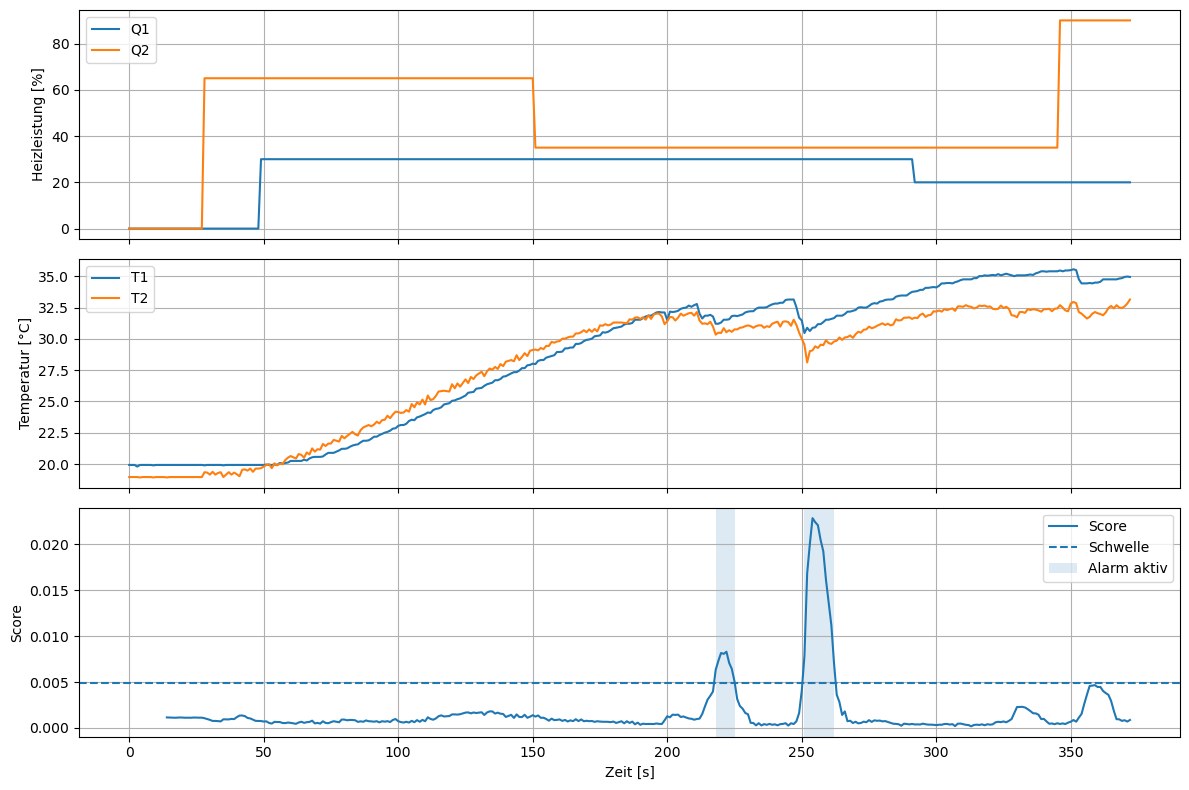

TCLab disconnected successfully.


KeyboardInterrupt: 

In [43]:
# Diese Zelle nur ausführen, wenn echte Hardware angeschlossen ist.

live_results_df = run_live_demo_with_selected_model(
    profile_df=live_profile_df,
    feature_cols=CONFIG["feature_cols"],
    model_name=selected_live_model,
    artifacts=live_artifacts,
    threshold=live_threshold,
    window_length_s=CONFIG["window_length_s"],
    plot_update_every=CONFIG["live_plot_update_every"],
)

## Fazit

In diesem Notebook wurde gezeigt, dass Modelle aus der Simulation auf realen Normaldaten oft zusätzliche Fehlalarme erzeugen.

Wichtige Beobachtungen:

- Der **Zero-shot-Transfer** auf reale Daten ist oft problematisch.
- Eine **Neukalibrierung der Schwelle** kann Fehlalarme bereits spürbar reduzieren.
- Ein **Nachtraining auf realen Normaldaten** verbessert die Übertragbarkeit meist noch stärker.
- Für die praktische Nutzung auf der Hardware ist die Wahl eines geeigneten Modells und einer geeigneten Kalibrierung entscheidend.

## Eigene Notizen

- Welches Modell war im Zero-shot-Transfer am robustesten?
- Wie stark hat die Schwellen-Neukalibrierung geholfen?
- Wie stark hat das Nachtraining geholfen?
- Welches Modell eignet sich am besten für die qualitative Live-Demo?
- Welche Unterschiede zwischen Simulation und Realität waren besonders auffällig?